In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
os.chdir("/lscratch/fgmaion/MTNG-resims/src")
import utils

In [4]:
filename = "/scratch/fgmaion/CAMELS/1P/info.txt"

data = {}
with open(filename) as f:
    lines = f.readlines()
    for i in range(1,len(lines)):
        lines[i].strip()
        columns = [item.strip() for item in lines[i].split(',')]
        data[i] = {'Name':columns[0], 'AbsMaxDiff':float(columns[1]), 'LogFlag':int(columns[2]), 'FidVal':float(columns[3]), 'MinVal':float(columns[4]), 'MaxVal':float(columns[5]), 'Desc':columns[6]}


/lscratch/fgmaion/MTNG-resims/src/utils.py:653: RuntimeWarning: divide by zero encountered in divide
  _sSFR = 1e10 * f['Subhalo/SubhaloSFR'][:] / _mstar
/lscratch/fgmaion/MTNG-resims/src/utils.py:653: RuntimeWarning: invalid value encountered in divide
  _sSFR = 1e10 * f['Subhalo/SubhaloSFR'][:] / _mstar
/lscratch/fgmaion/miniconda3/envs/condaenv/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/lscratch/fgmaion/miniconda3/envs/condaenv/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/lscratch/fgmaion/MTNG-resims/src/utils.py:653: RuntimeWarning: divide by zero encountered in divide
  _sSFR = 1e10 * f['Subhalo/SubhaloSFR'][:] / _mstar
/lscratch/fgmaion/MTNG-resims/src/utils.py:653: RuntimeWarning: invalid value encountered in divide
  _sSFR = 1e10 * f['Subhalo/SubhaloSFR'][:] / _mstar
/lscrat

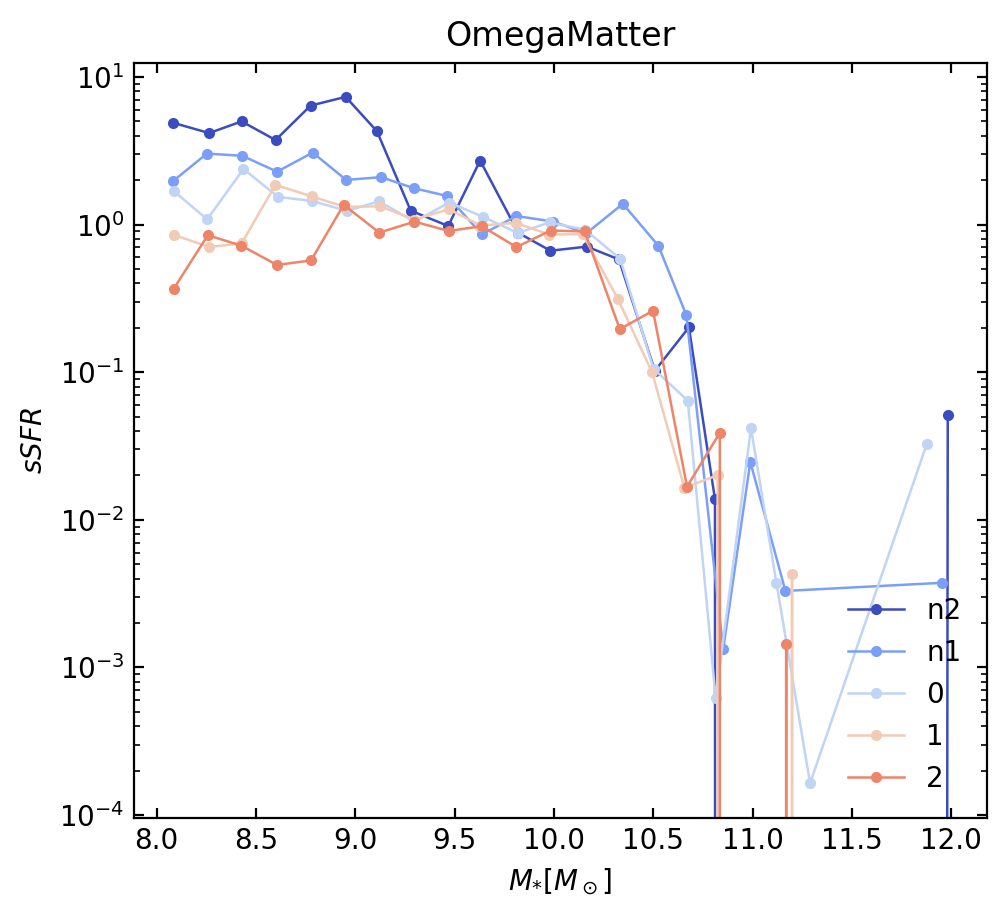

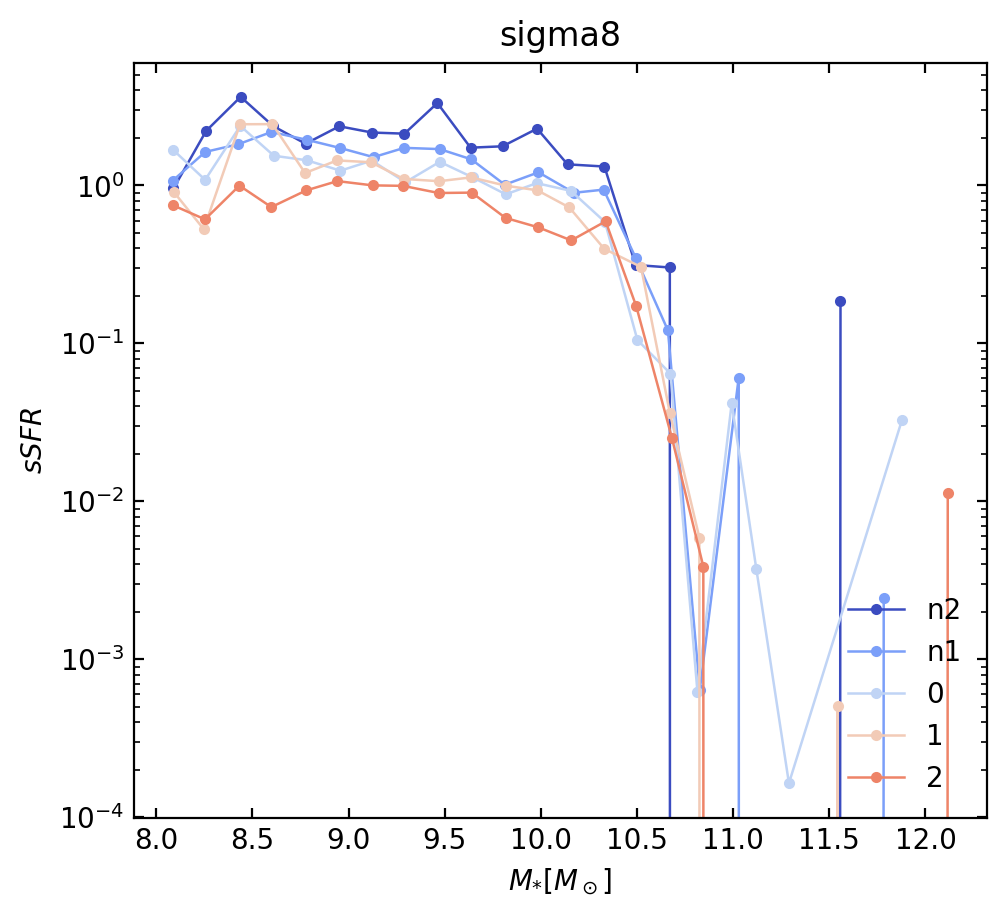

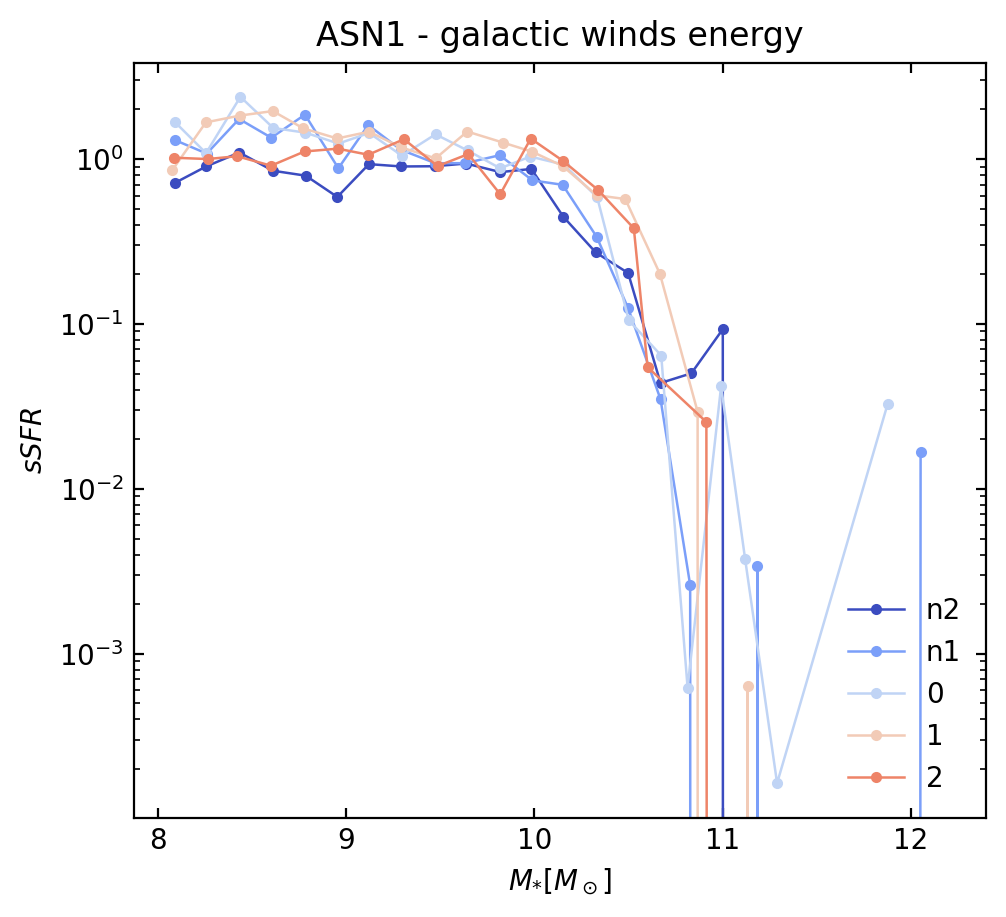

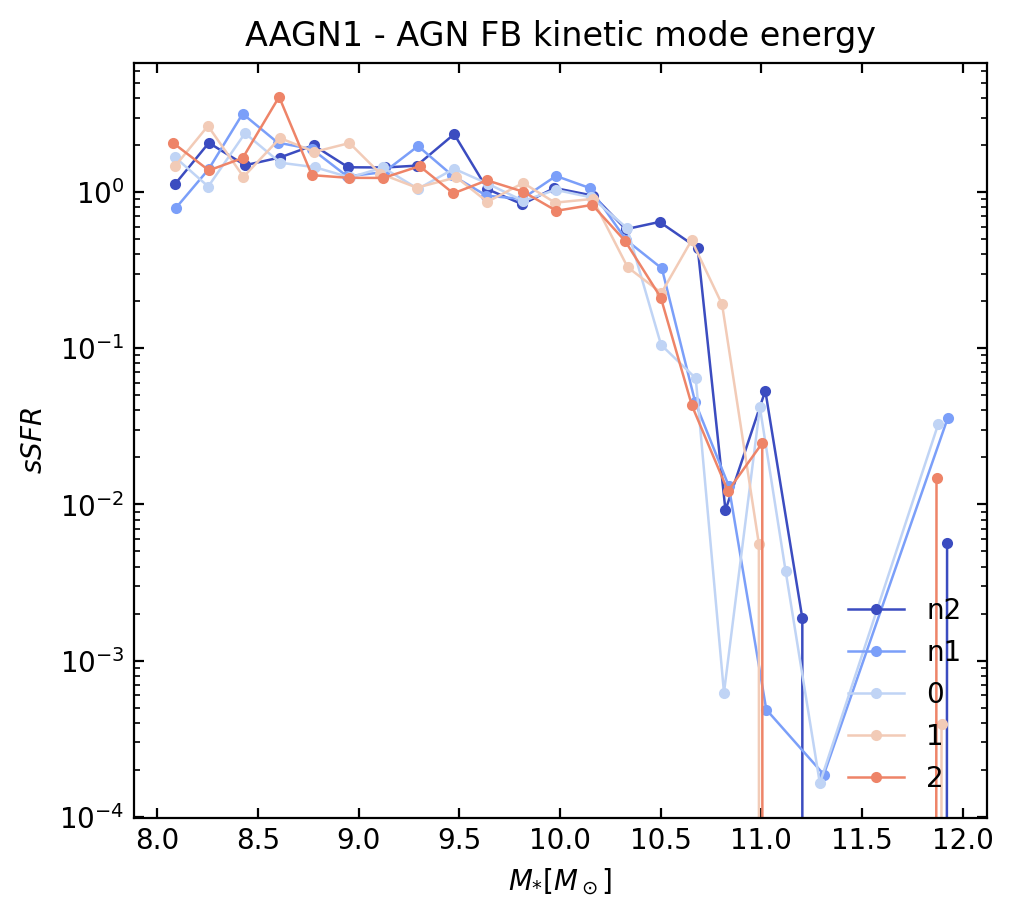

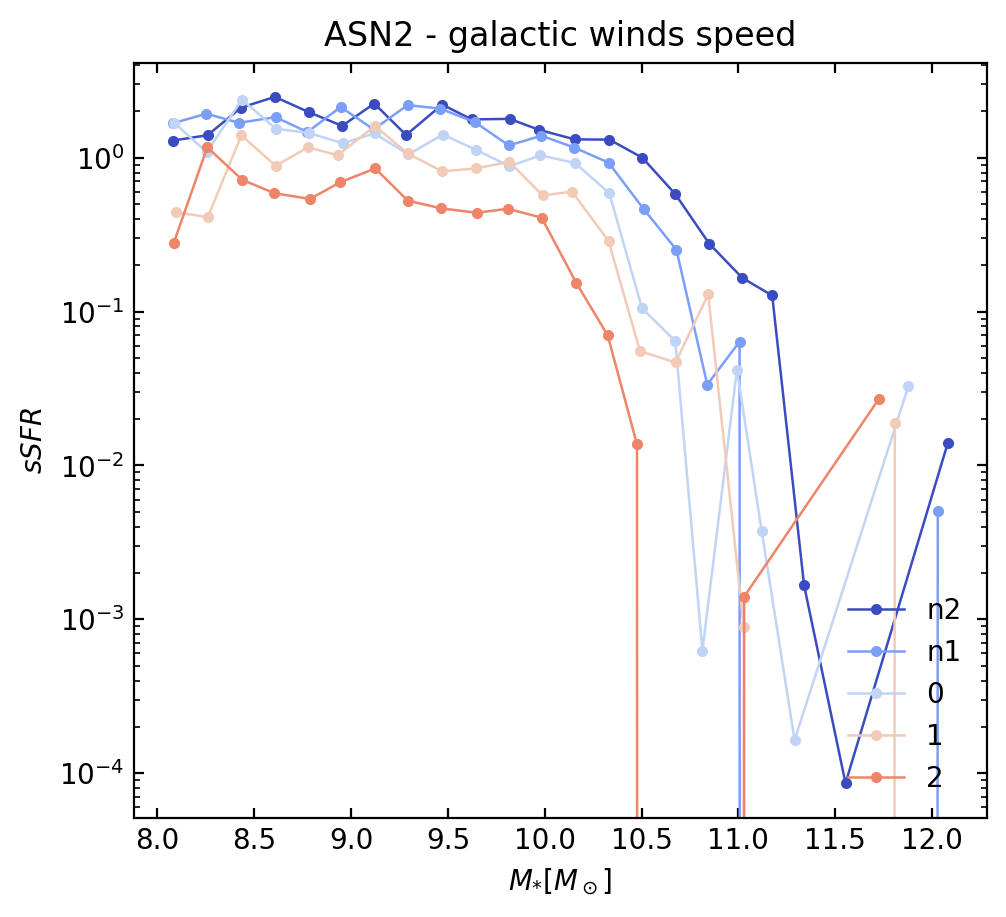

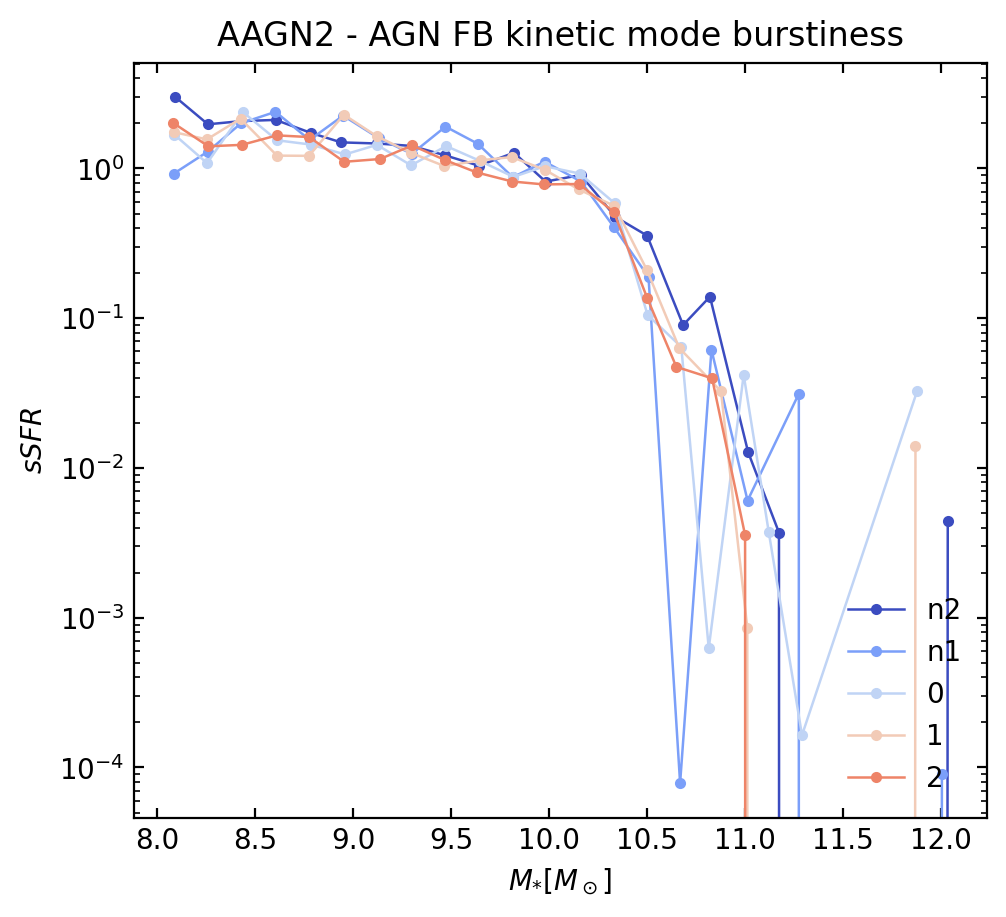

In [21]:
for par in range(1,7):
    sSFR = {}
    if par!=15:
        index = ['n2', 'n1', '0', '1', '2']
    else:
        index = ['0', '1', '2', '3', '4']
    for i in range(5):
        sSFR[index[i]] = utils.camels_sSFR(index[i], par, nbins=20)

    fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

    ax.set_yscale('log')

    ax.set_title(data[par]['Desc'])

    cmap = matplotlib.cm.get_cmap('coolwarm')
    labels=['n2', 'n1', '0', '1', '2']

    for i in range(5):
        sel = np.where(~np.isnan(sSFR[index[i]]['sSFR']))
        ax.plot(np.log10(sSFR[index[i]]['mstar'])[sel], sSFR[index[i]]['sSFR'][sel], color=cmap(i/5), label=labels[i], marker='o', ms=3, lw=0.9)

    ax.legend(loc='lower right')

    ax.set_ylabel('$sSFR$')
    ax.set_xlabel('$M_{*}[M_\odot]$')

    plt.savefig('/scratch/fgmaion/CAMELS/figures/sSFR_1P_'+data[par]['Name']+'.pdf', bbox_inches='tight')

/lscratch/fgmaion/MTNG-resims/src/utils.py:653: RuntimeWarning: divide by zero encountered in divide
  _sSFR = 1e10 * f['Subhalo/SubhaloSFR'][:] / _mstar
/lscratch/fgmaion/MTNG-resims/src/utils.py:653: RuntimeWarning: invalid value encountered in divide
  _sSFR = 1e10 * f['Subhalo/SubhaloSFR'][:] / _mstar
/lscratch/fgmaion/miniconda3/envs/condaenv/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/lscratch/fgmaion/miniconda3/envs/condaenv/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/lscratch/fgmaion/MTNG-resims/src/utils.py:653: RuntimeWarning: divide by zero encountered in divide
  _sSFR = 1e10 * f['Subhalo/SubhaloSFR'][:] / _mstar
/lscratch/fgmaion/MTNG-resims/src/utils.py:653: RuntimeWarning: invalid value encountered in divide
  _sSFR = 1e10 * f['Subhalo/SubhaloSFR'][:] / _mstar
/lscrat

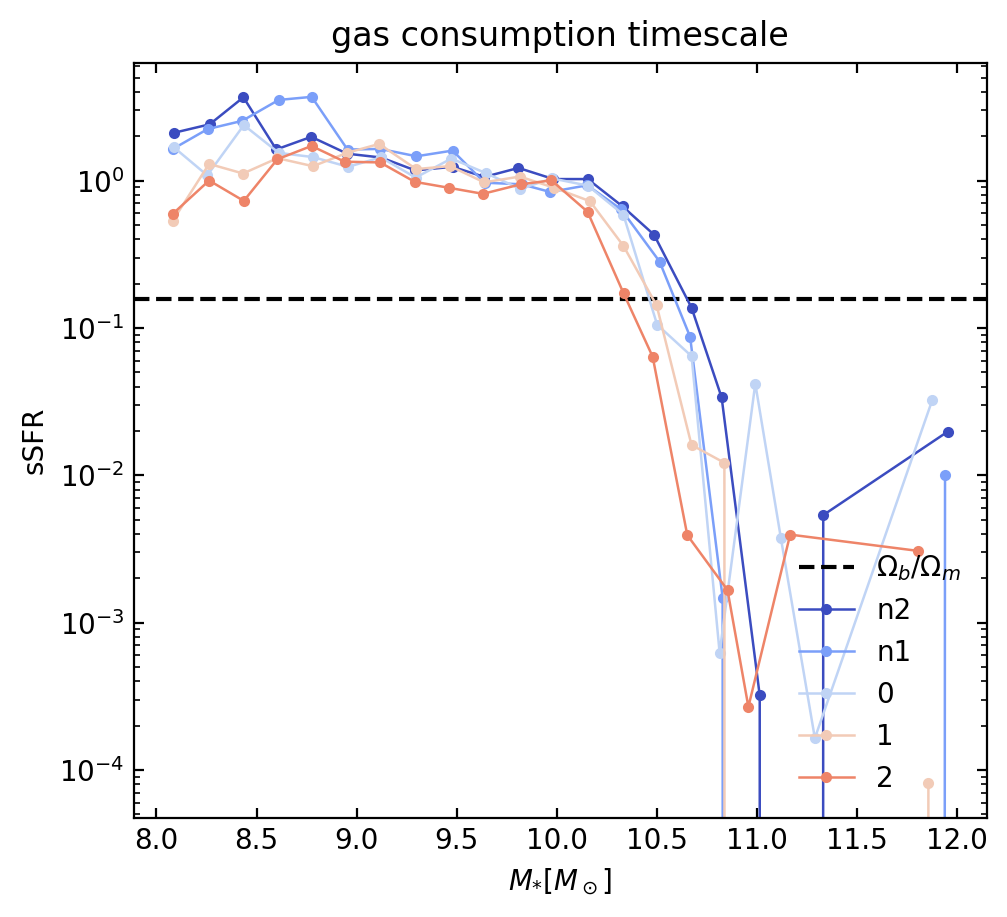

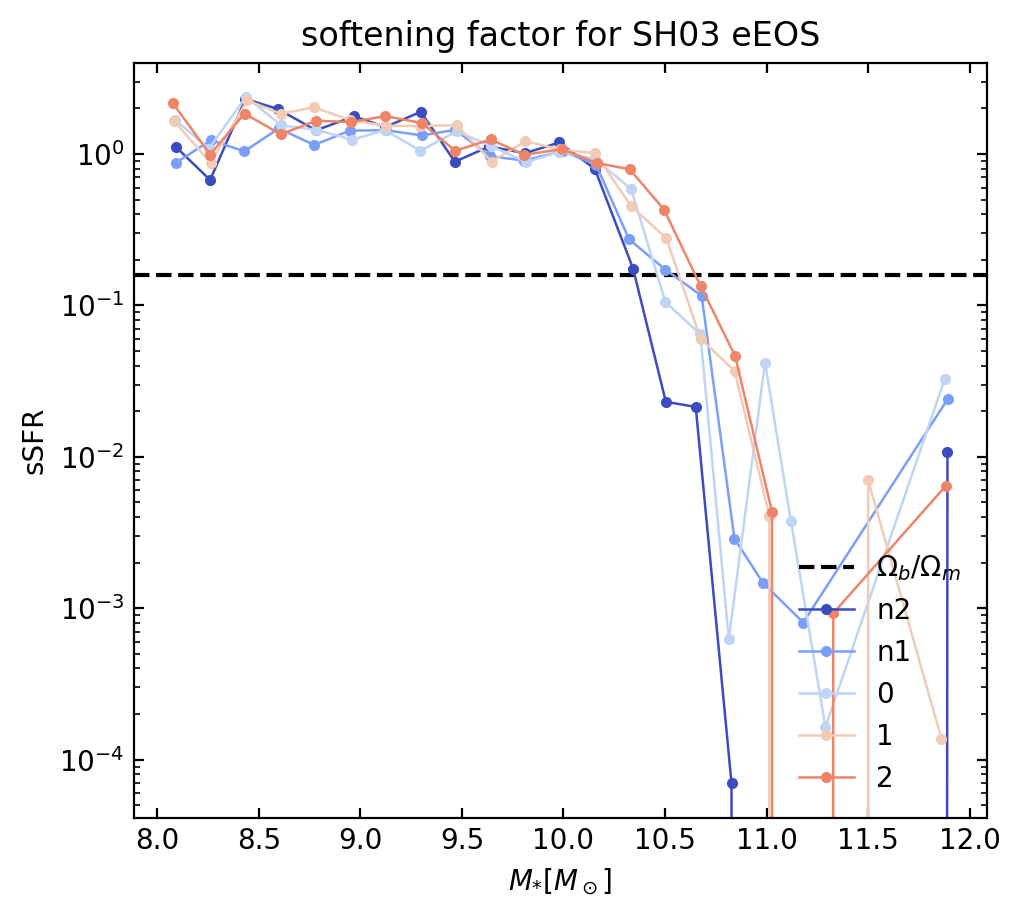

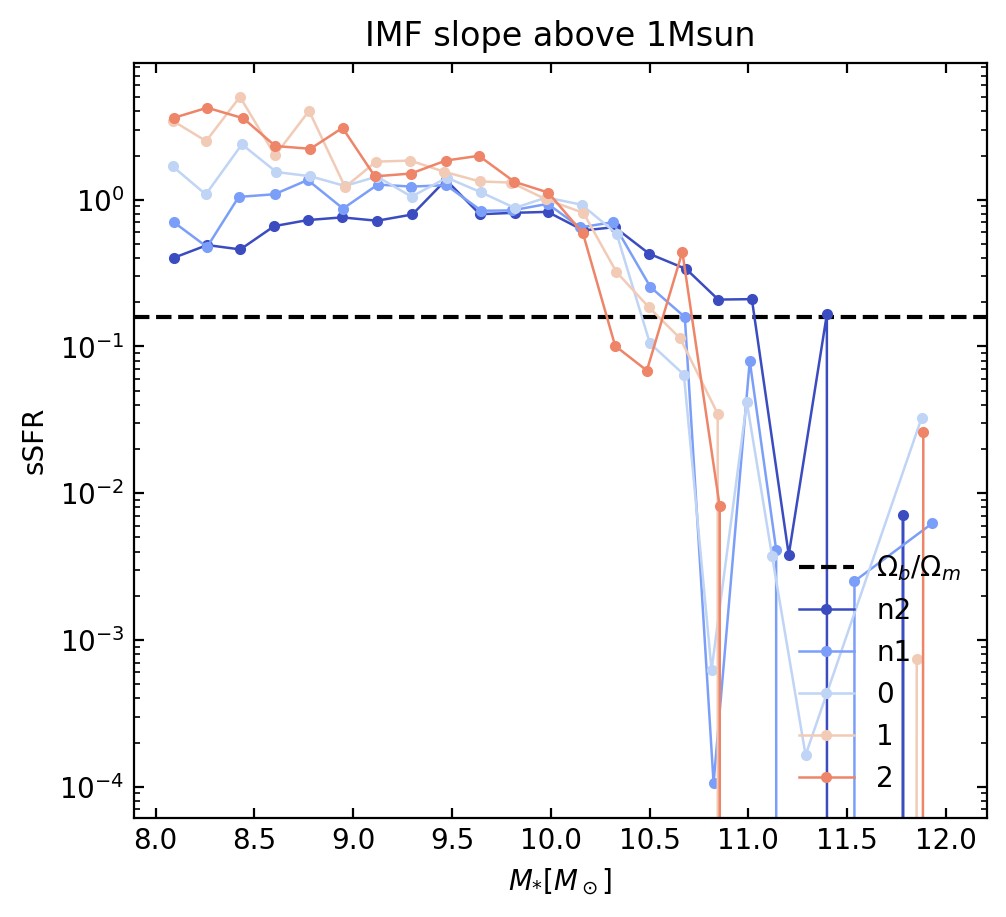

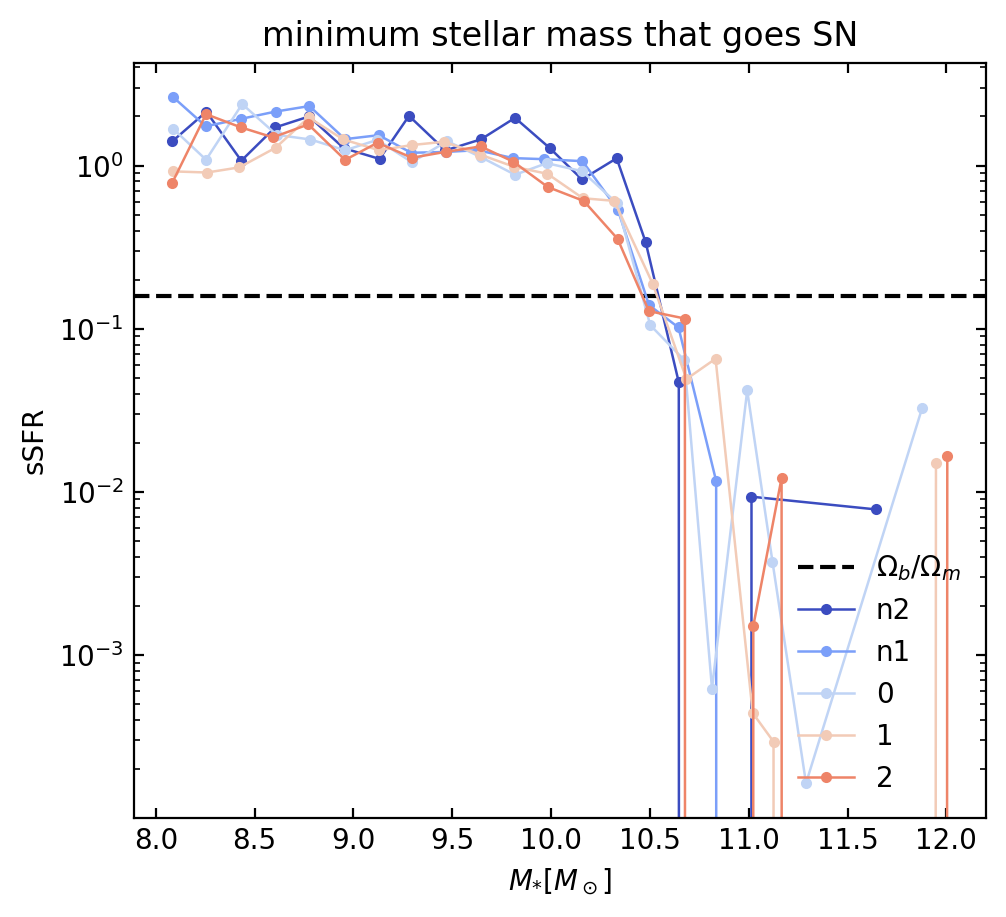

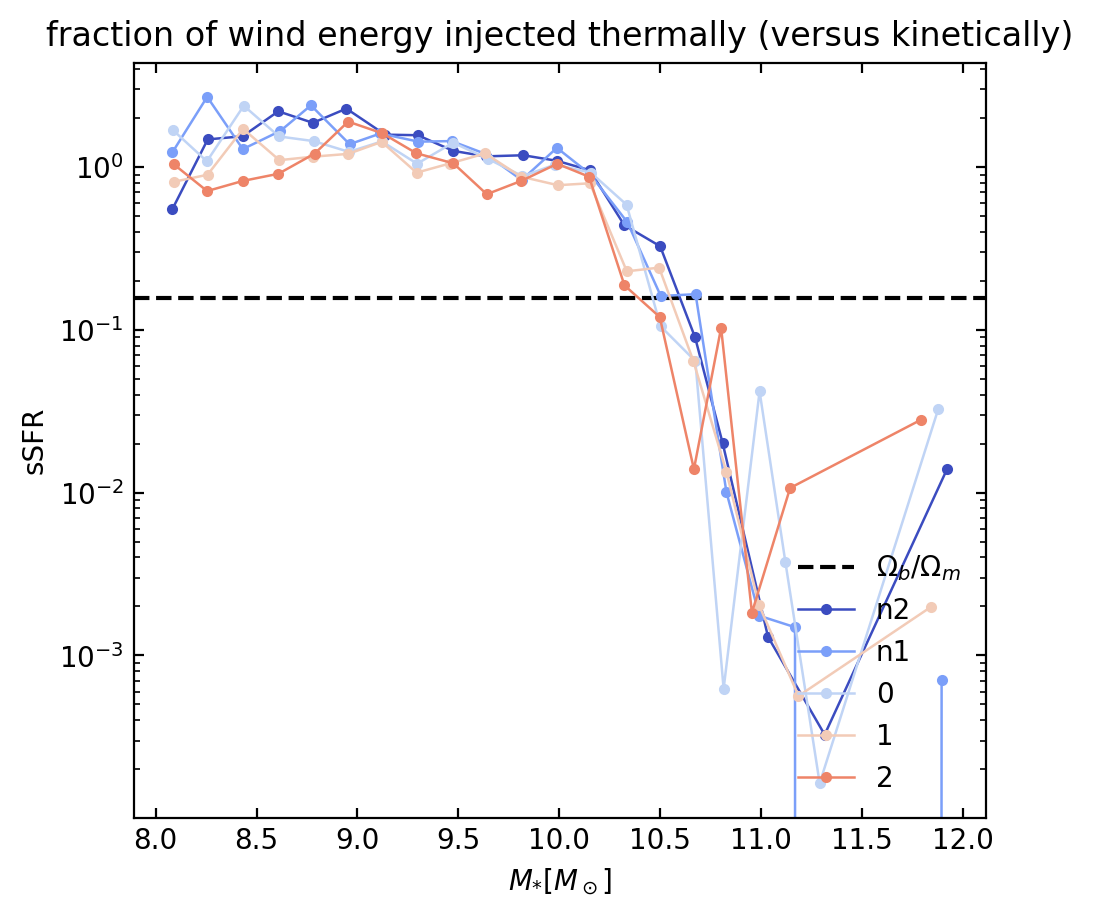

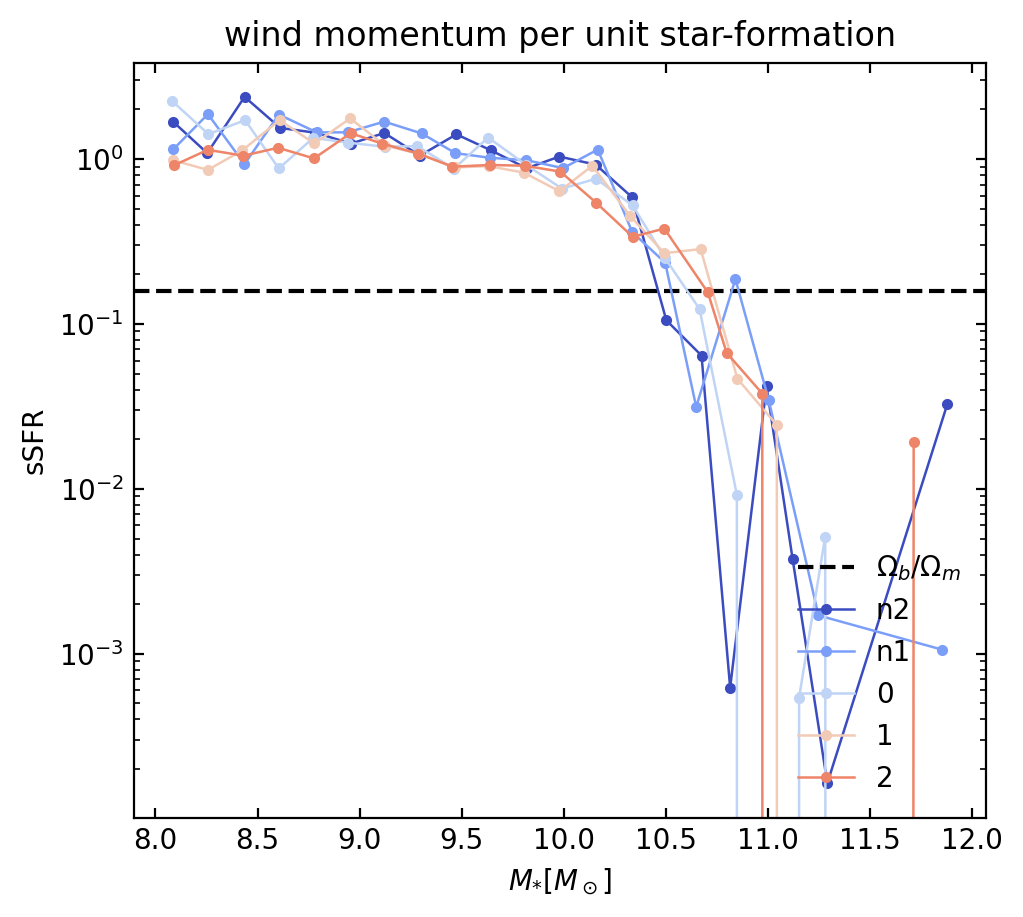

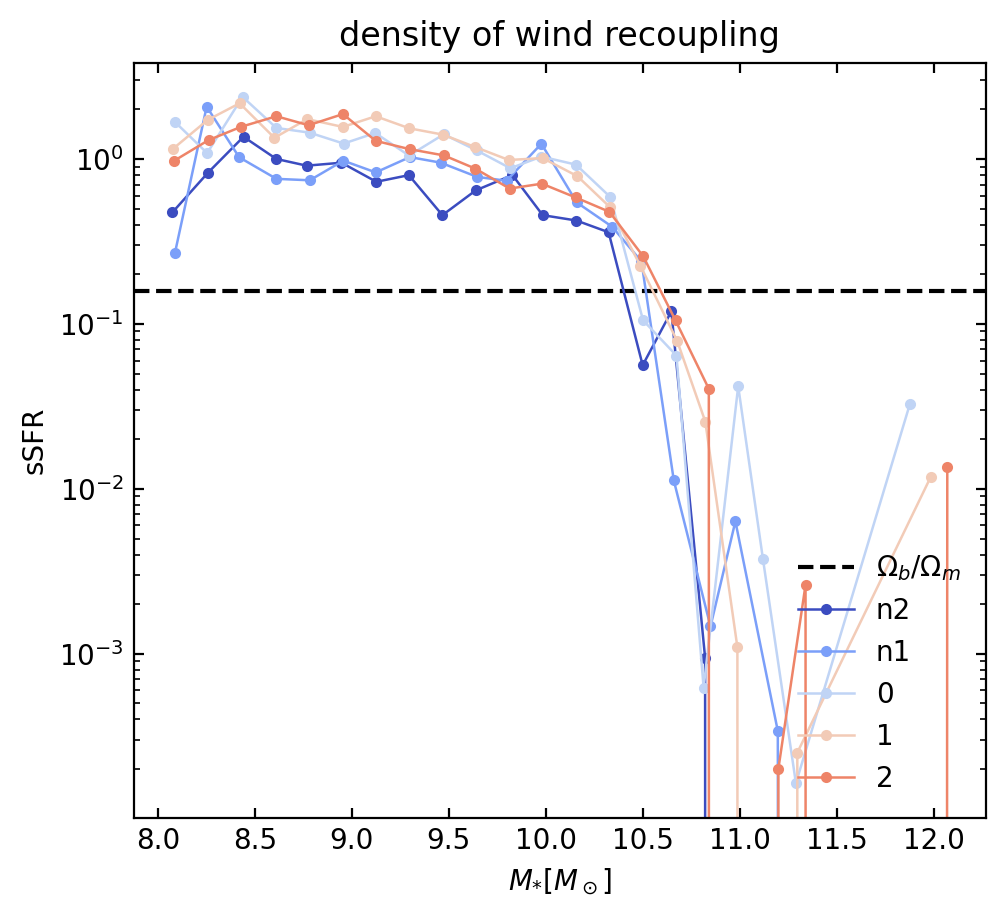

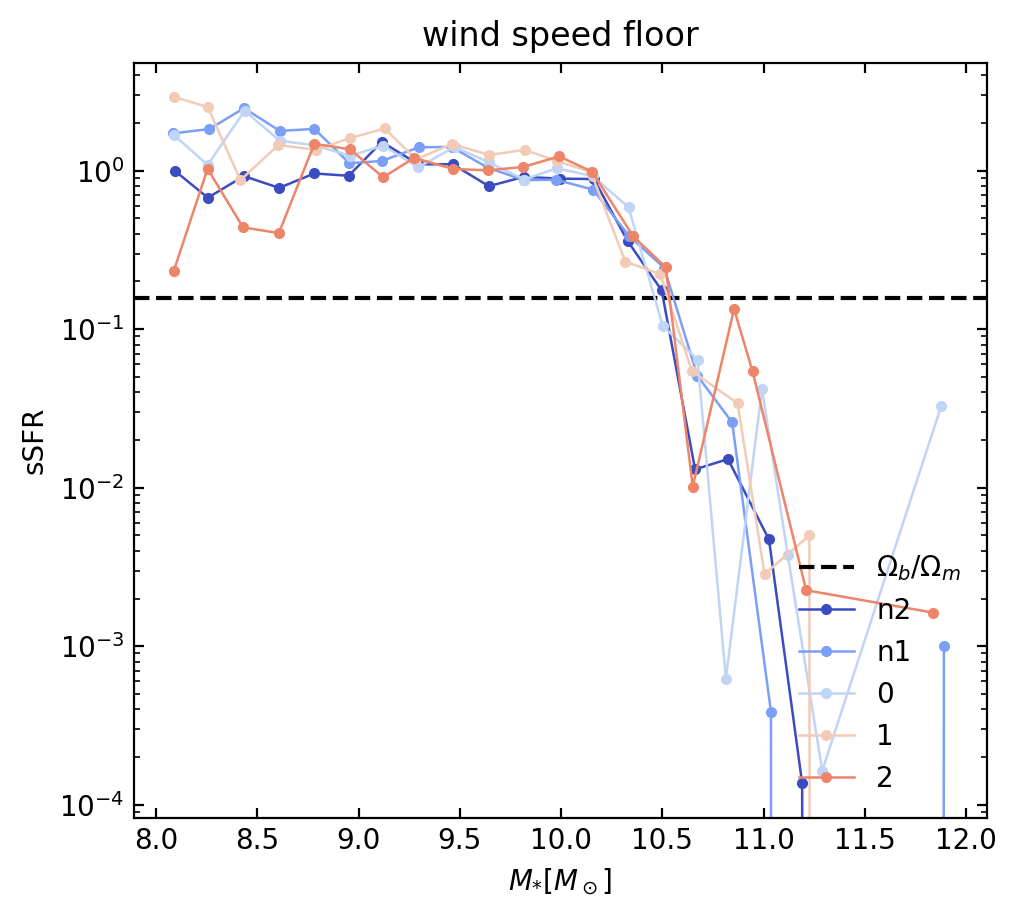

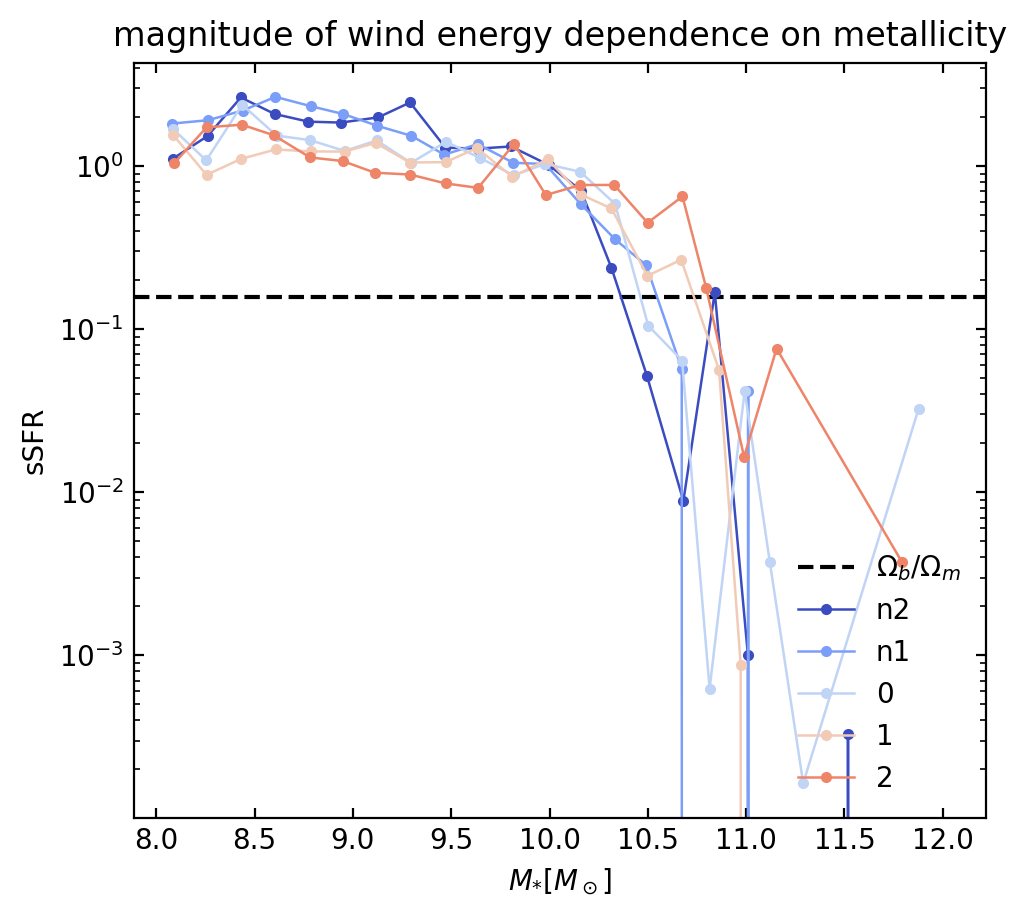

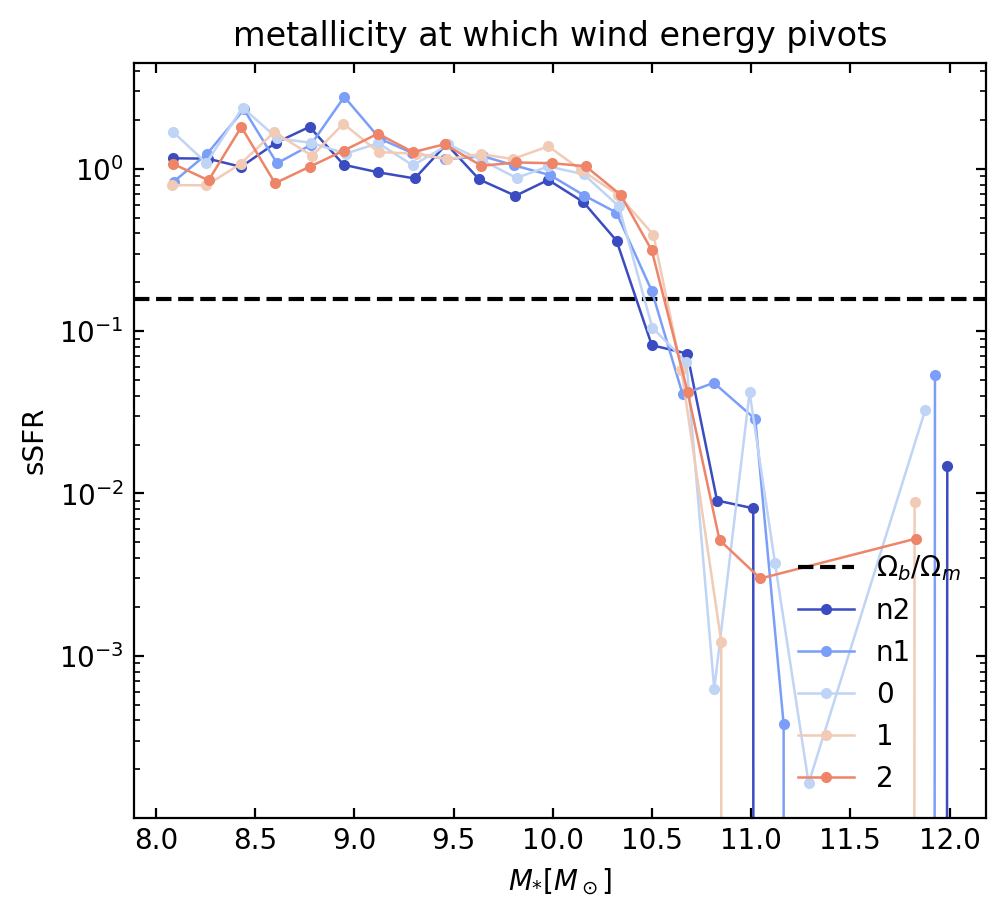

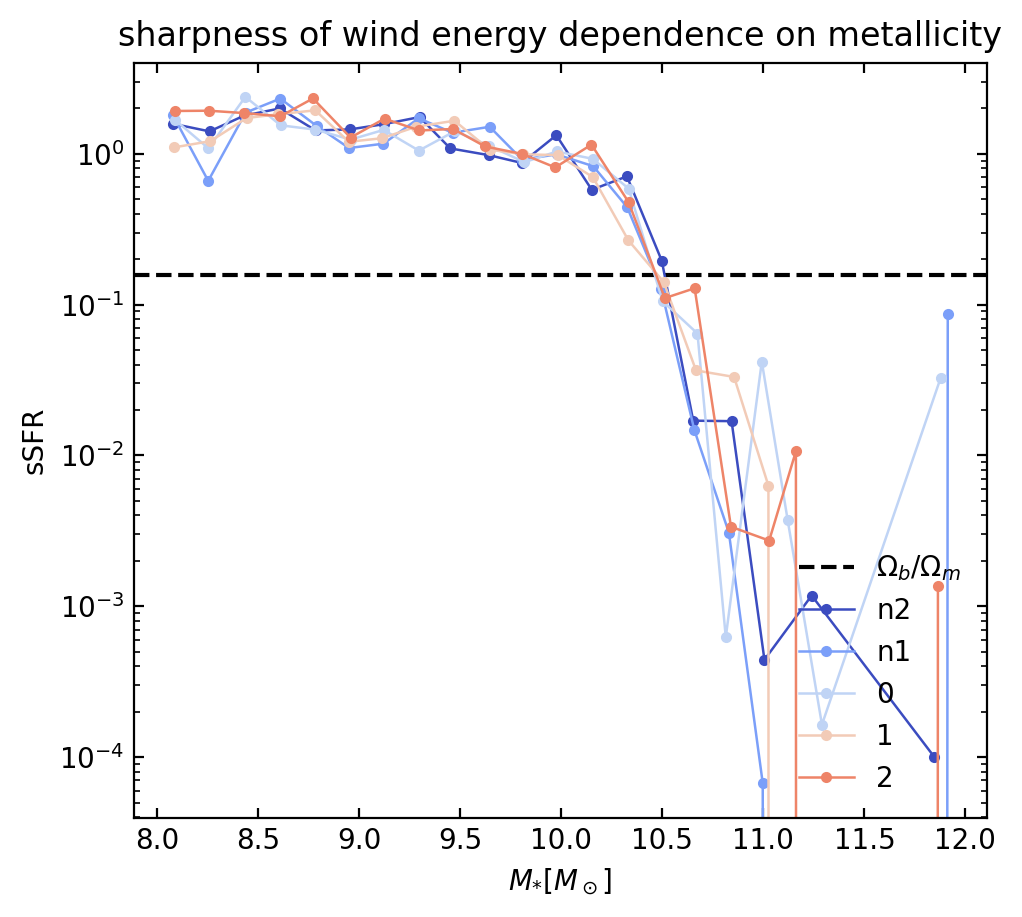

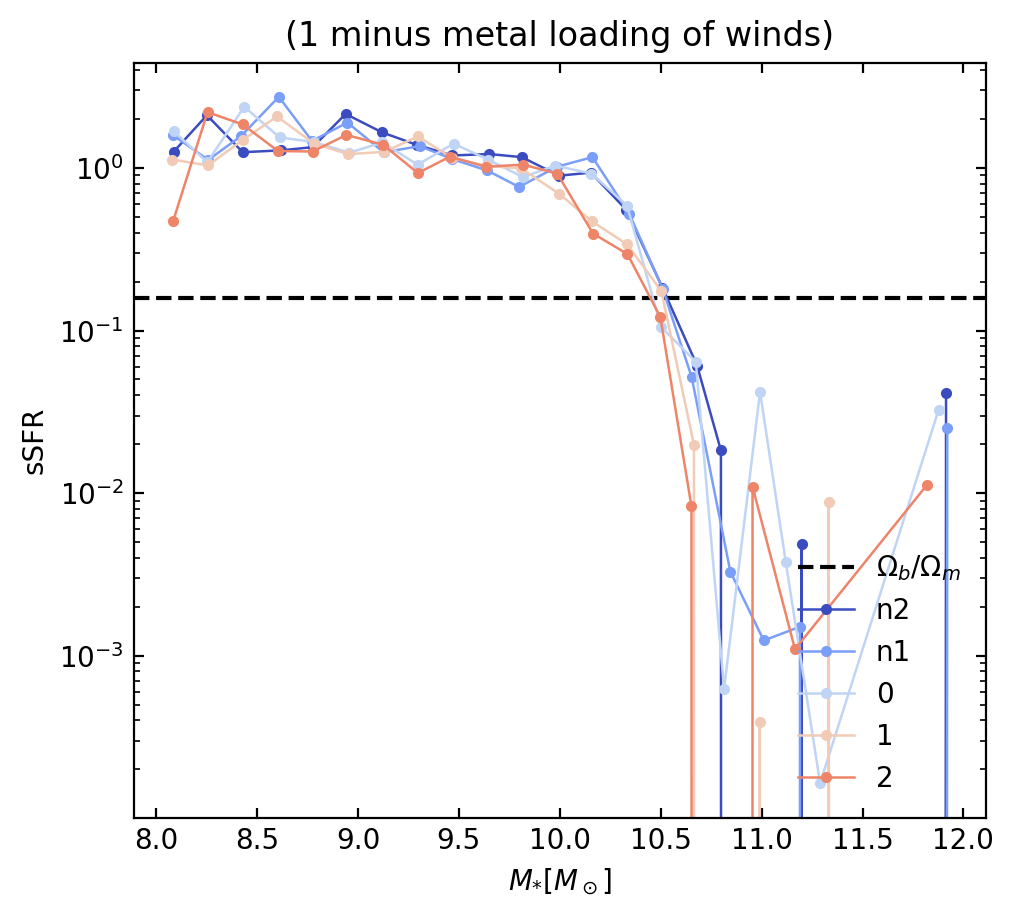

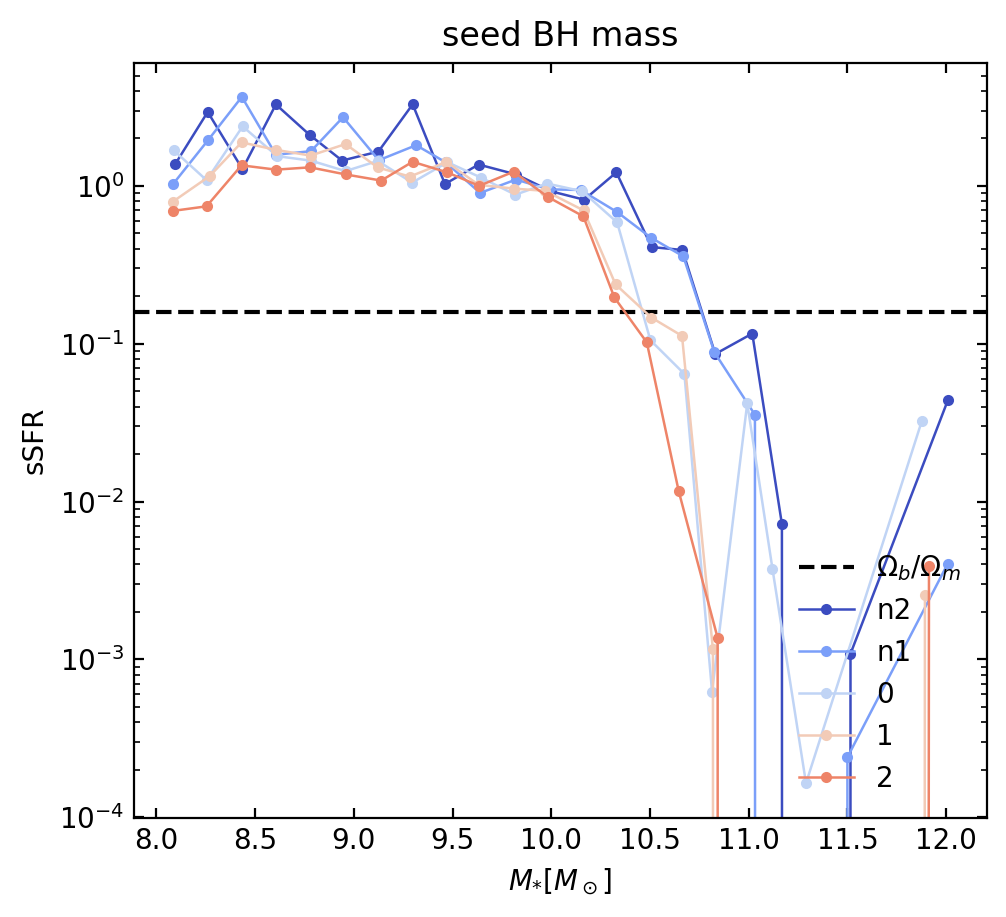

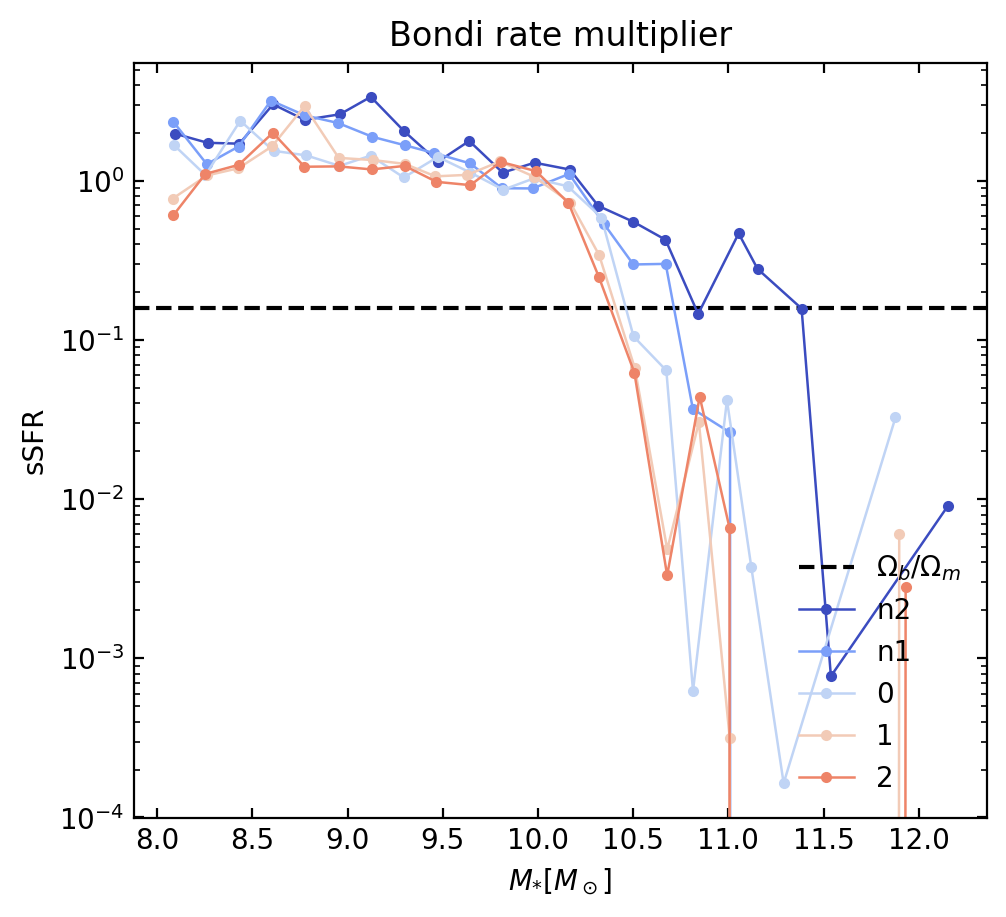

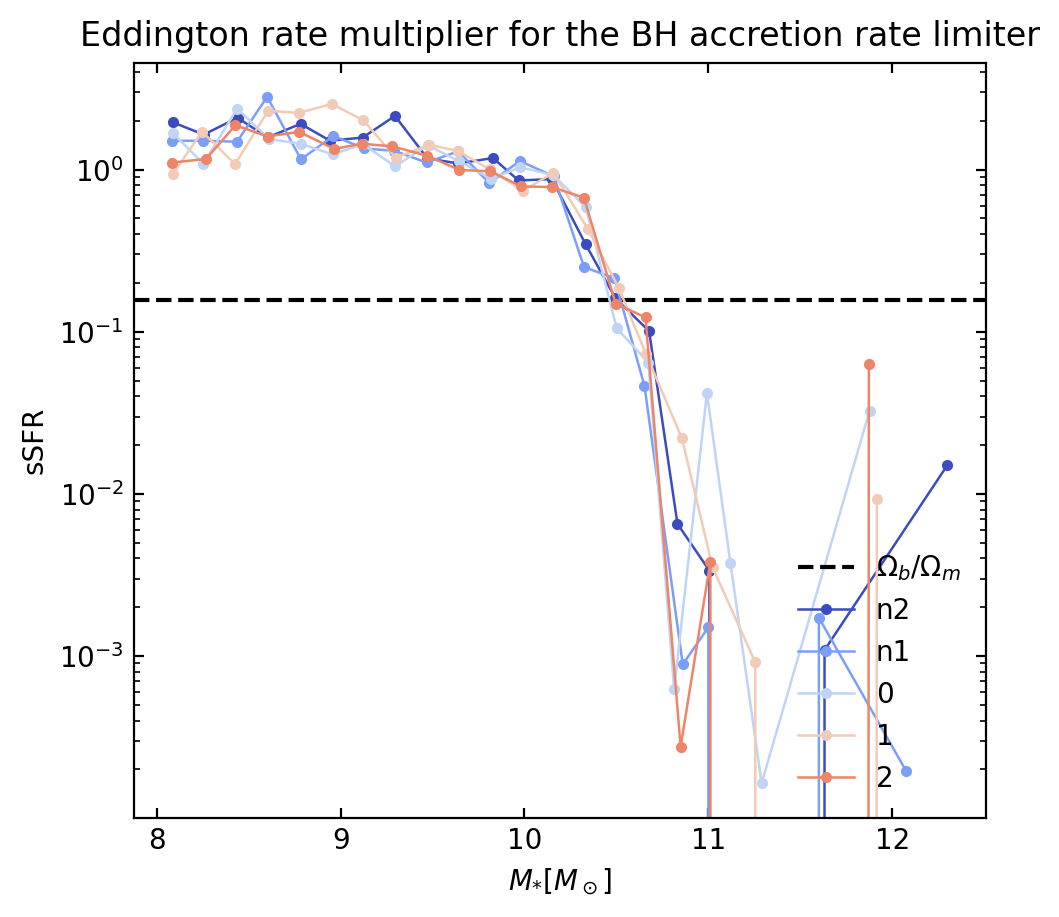

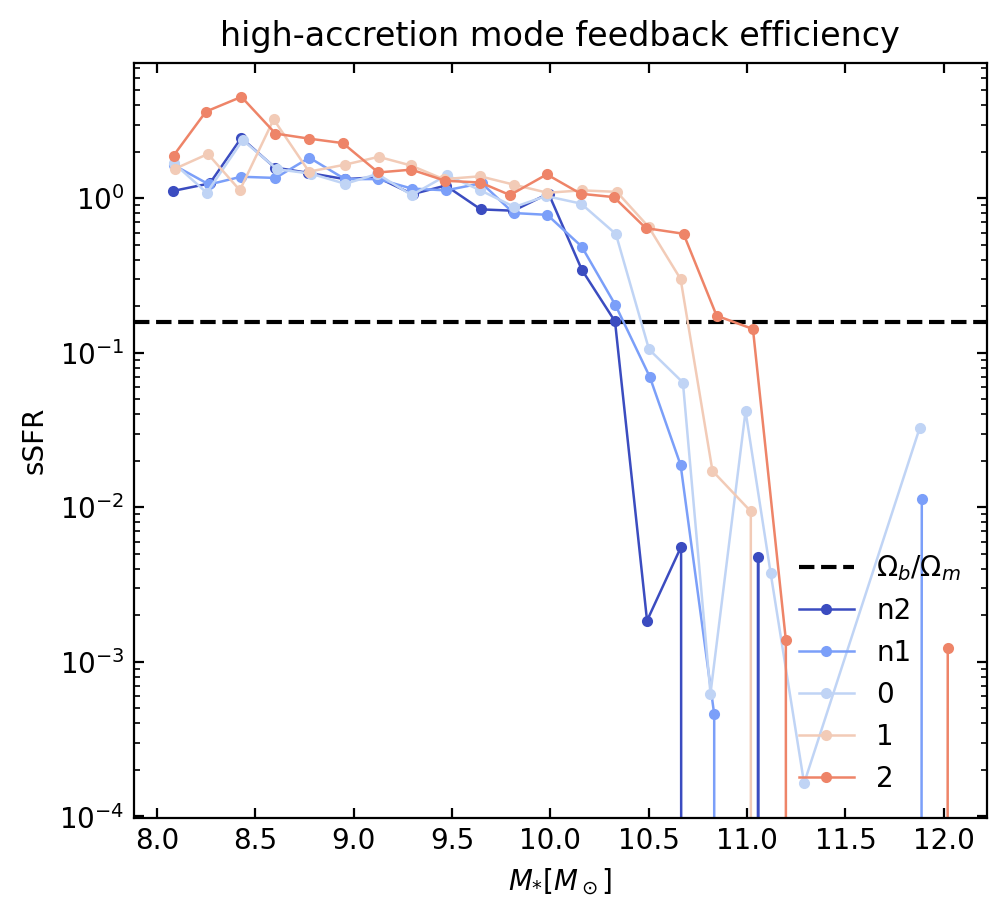

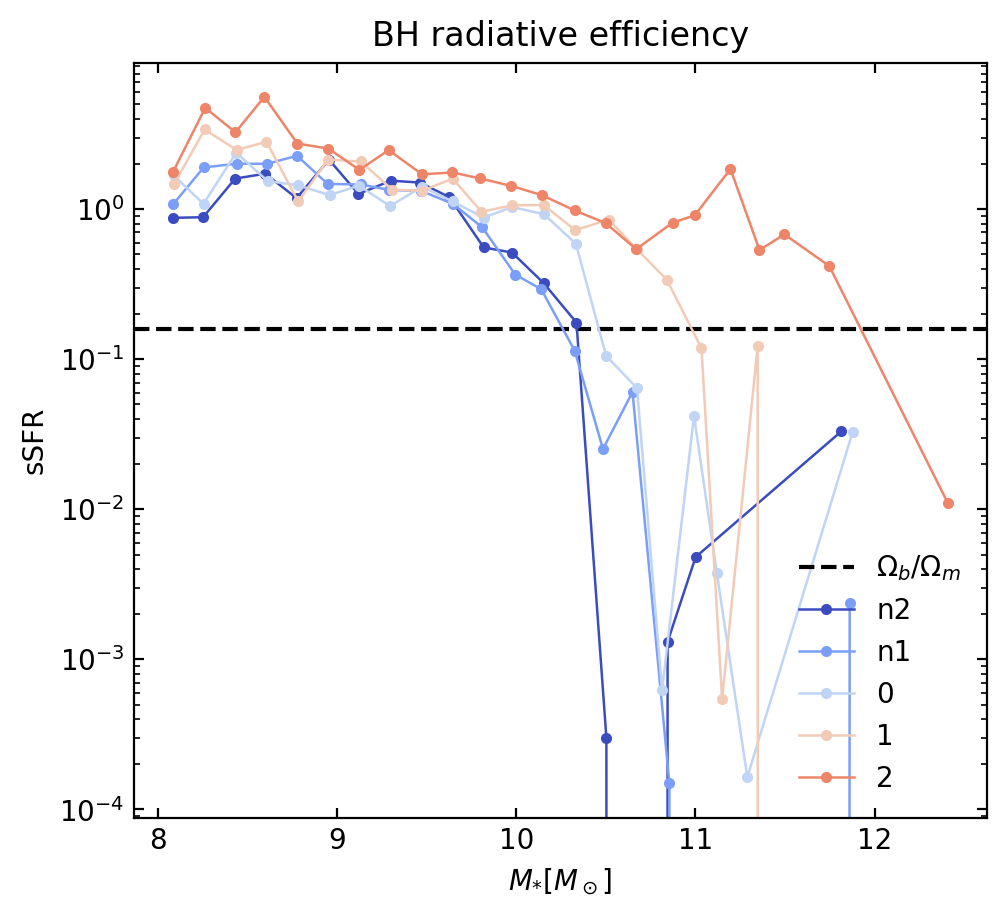

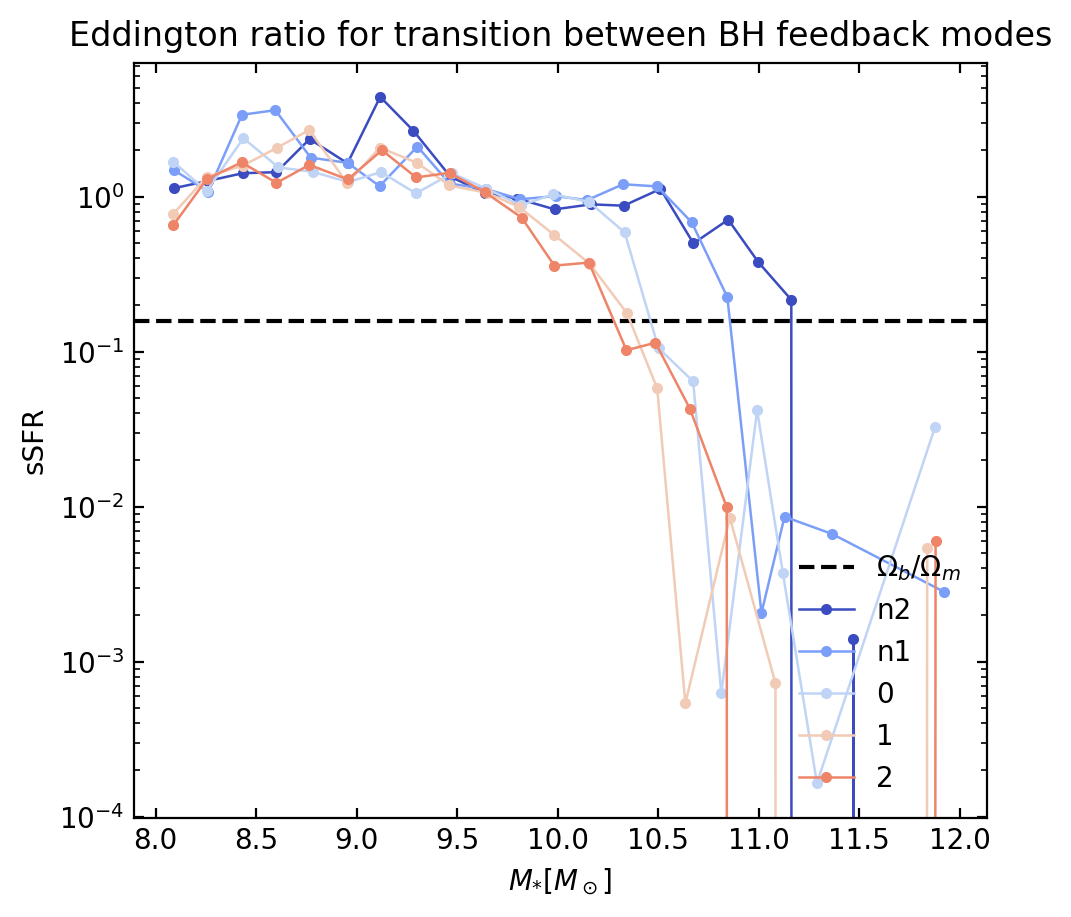

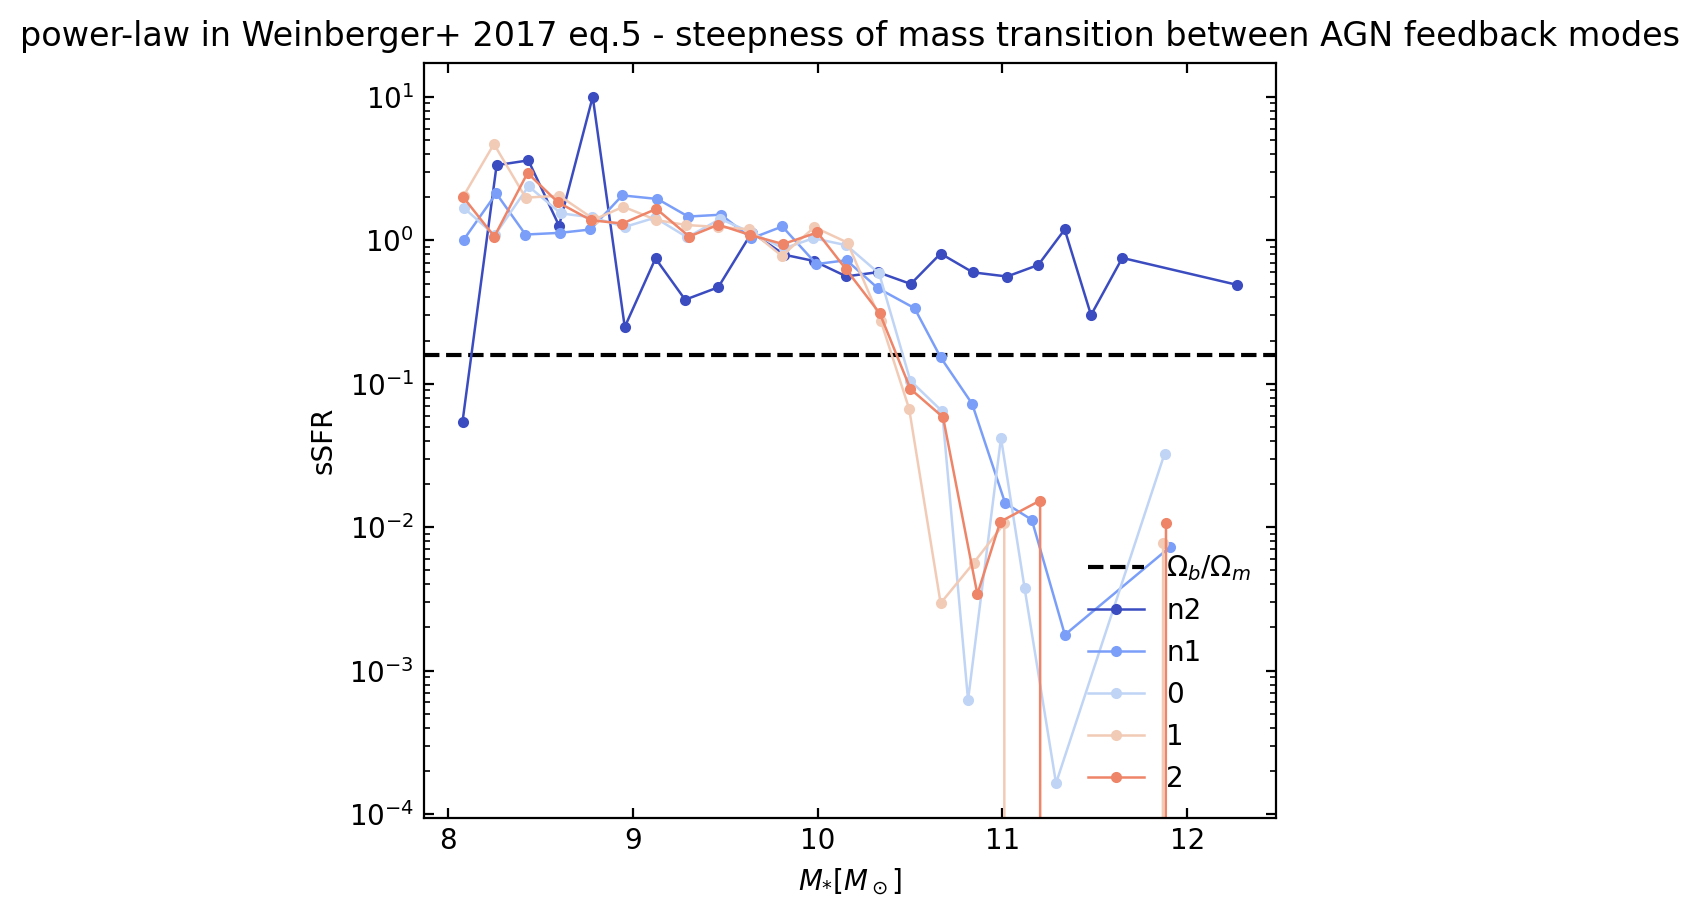

In [22]:
for par in range(10,29):
    sSFR = {}
    if par!=15:
        index = ['n2', 'n1', '0', '1', '2']
    else:
        index = ['0', '1', '2', '3', '4']
    for i in range(5):
        sSFR[index[i]] = utils.camels_sSFR(index[i], par, nbins=20)

    fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

    ax.set_title(data[par]['Desc'])

    ax.set_yscale('log')

    cmap = matplotlib.cm.get_cmap('coolwarm')
    labels=['n2', 'n1', '0', '1', '2']

    ax.axhline(0.158, color='k', label='$\Omega_b/\Omega_m$', ls='--')

    for i in range(5):
        sel = np.where(~np.isnan(sSFR[index[i]]['sSFR']))
        ax.plot(np.log10(sSFR[index[i]]['mstar'])[sel], sSFR[index[i]]['sSFR'][sel], color=cmap(i/5), label=labels[i], marker='o', ms=3, lw=0.9)

    ax.legend(loc='lower right')

    ax.set_ylabel('sSFR')
    ax.set_xlabel('$M_{*}[M_\odot]$')

    plt.savefig('/scratch/fgmaion/CAMELS/figures/sSFR_1P_'+data[par]['Name']+'.pdf', bbox_inches='tight')

In [ ]:
fgas = utils.camels_gas_frac('n2', 3, nbins=20)

/lscratch/fgmaion/miniconda3/envs/condaenv/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/lscratch/fgmaion/miniconda3/envs/condaenv/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


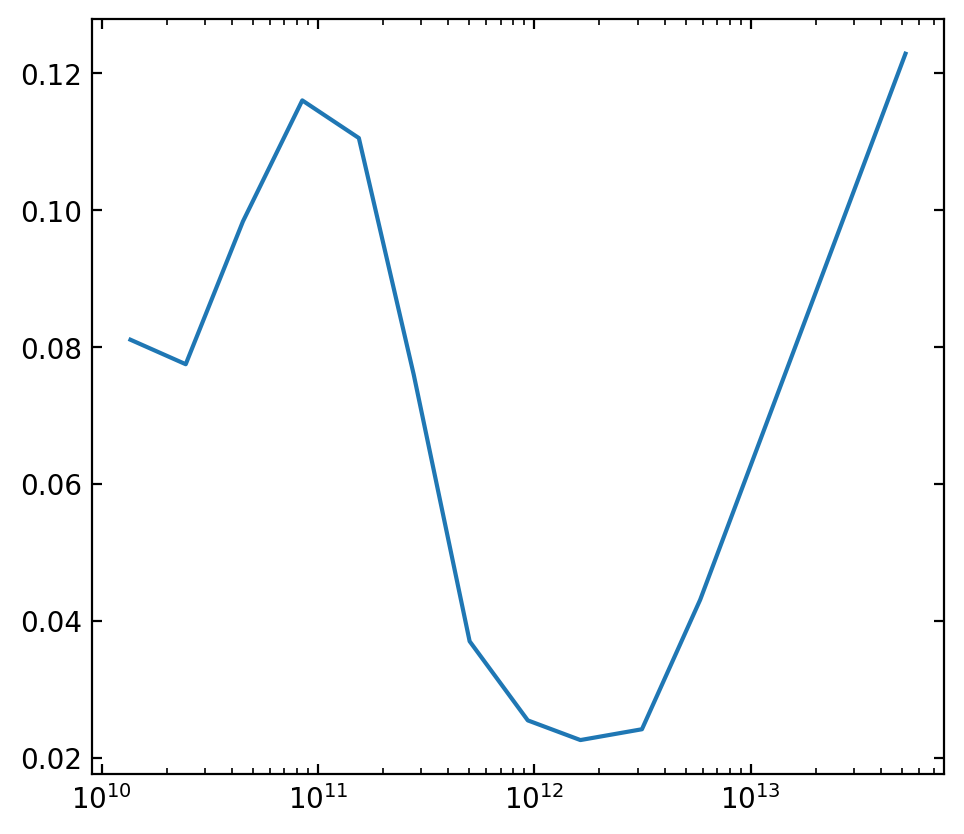

In [ ]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

ax.set_xscale('log')

sel = np.where(~np.isnan(fgas['f_gas']))
ax.plot(fgas['m500c'][sel], fgas['f_gas'][sel]  )